# 第一层：数学基础
## cross/ 研究路线 — 拓扑物态 × AI 的数学地基

**持续时间：** Month 0–4（线代+微积分立刻并行；概率论 Month 2 开始）

> 数学不是目的，是工具。每个模块只学「物理和 AI 真正用到的部分」，不追求全覆盖。

---

### 模块总览

| 模块 | 核心用途 | 书目 / 资源 | 优先级 | 时间窗口 |
|------|---------|------------|--------|----------|
| **线性代数** | 量子态 = 向量；哈密顿量 = 矩阵；GNN 消息传递 | Strang《Introduction to Linear Algebra》| ★★★★★ | Month 0–3 |
| **微积分** | 链式法则 = 反向传播；积分 = Berry 相位 | 3Blue1Brown 系列 + 工程教材 | ★★★★★ | Month 0–2 |
| **概率论与统计** | 量子测量统计；ML 损失函数；费米-狄拉克分布 | Blitzstein《Introduction to Probability》| ★★★★☆ | Month 2–5 |
| **复数分析** | 量子力学复数；Green 函数极点 | 工程教材复习 | ★★★★☆ | Month 1–3 |
| 微分几何入门 | 陈数积分；拓扑不变量的几何语言 | Nakahara 选读 | ★★★★☆ | **Phase 2（Month 12）** |
| 群论基础 | 晶体点群；等变神经网络的数学基础 | Dresselhaus 选读 | ★★★☆☆ | **Phase 2（Month 12）** |

> **微分几何和群论现在不学** — 它们依赖 Layer 3 的物理直觉，到了 Berry 相位那层再回来补，否则学了也记不住。

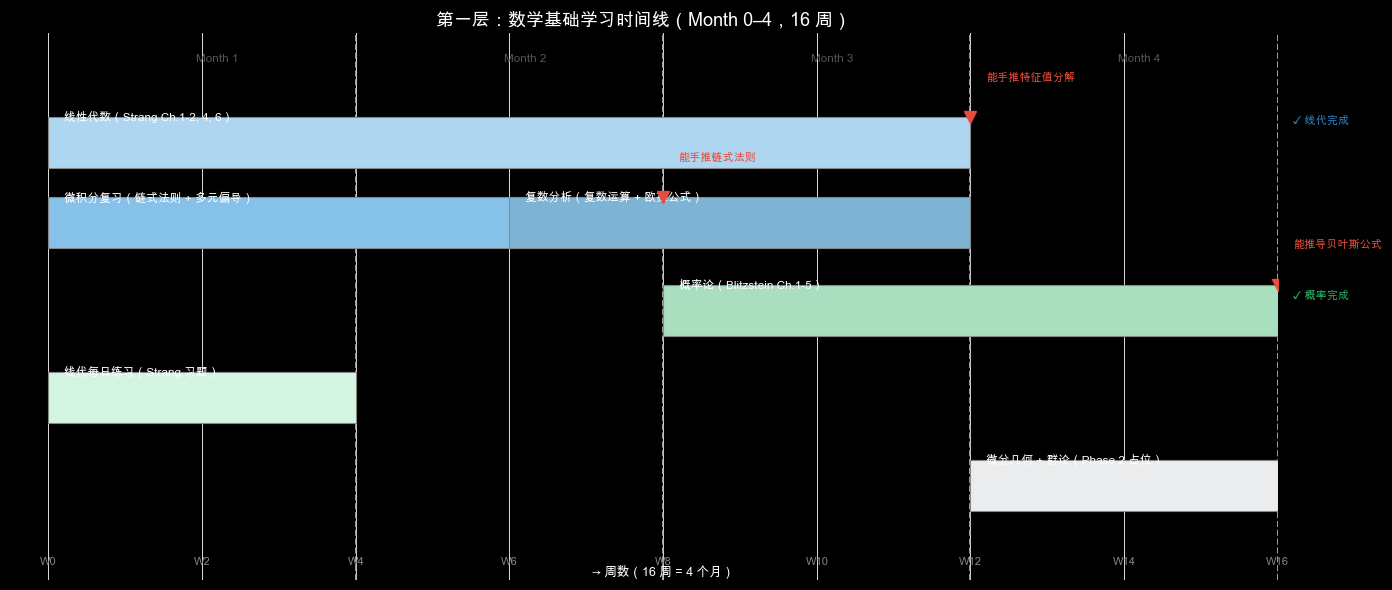

时间线生成完成


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(-0.5, 16)
ax.set_ylim(-0.5, 7)
ax.axis('off')

# 横轴（周）
for w in range(0, 17, 2):
    ax.axvline(w, color='#ddd', lw=0.7, zorder=0)
    ax.text(w, -0.3, f'W{w}', ha='center', fontsize=8, color='#888')
ax.text(8, -0.45, '→ 周数（16 周 = 4 个月）', ha='center', fontsize=9)

# 月份分割线
for m, label in [(4,'Month 1'), (8,'Month 2'), (12,'Month 3'), (16,'Month 4')]:
    ax.axvline(m, color='#bbb', lw=1.2, linestyle='--', zorder=0)
    ax.text(m-1.8, 6.6, label, ha='center', fontsize=8.5, color='#555')

# 各模块条形
# (y, start_week, end_week, label, color, milestone_week, milestone_text)
bars = [
    (5.5, 0,  12, '线性代数（Strang Ch.1-2, 4, 6）',         '#AED6F1', 12, '能手推特征值分解'),
    (4.4, 0,  8,  '微积分复习（链式法则 + 多元偏导）',          '#85C1E9', 8,  '能手推链式法则'),
    (4.4, 6,  12, '复数分析（复数运算 + 欧拉公式）',             '#7FB3D3', None, ''),
    (3.2, 8,  16, '概率论（Blitzstein Ch.1-5）',               '#A9DFBF', 16, '能推导贝叶斯公式'),
    (2.0, 0,  4,  '线代每日练习（Strang 习题）',                '#D5F5E3', None, ''),
    (0.8, 12, 16, '微分几何 + 群论（Phase 2 占位）',            '#EAECEE', None, '（到 Layer 3 再学）'),
]

bh = 0.7
for y, s, e, label, color, ms, ms_text in bars:
    ax.barh(y, e-s, left=s, height=bh, color=color, edgecolor='#888', lw=0.8, zorder=2)
    ax.text(s+0.2, y+bh/2, label, va='center', fontsize=8.5, zorder=3)
    if ms:
        ax.plot(ms, y+bh/2, 'v', color='#E74C3C', ms=9, zorder=5)
        ax.text(ms+0.2, y+bh/2+0.5, ms_text, fontsize=8, color='#E74C3C', fontweight='bold')

# 里程碑标注
ax.text(16.2, 5.8, '✓ 线代完成', fontsize=8, color='#2980B9', va='center')
ax.text(16.2, 3.4, '✓ 概率完成', fontsize=8, color='#27AE60', va='center')

ax.set_title('第一层：数学基础学习时间线（Month 0–4，16 周）', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('时间线生成完成')

---
## 模块一：线性代数
**书目：** Strang《Introduction to Linear Algebra》（5th Ed.）

### 必读章节与核心概念

| 章节 | 核心概念 | 和物理/AI 的联系 | 周数 |
|------|---------|----------------|------|
| **Ch.1** 向量与线性组合 | 向量、点积、线性组合 | 量子态 = 向量；叠加 = 线性组合 | W1–2 |
| **Ch.2** 线性方程组 | 消元法、矩阵运算、LU 分解 | 哈密顿量方程组、数值解法基础 | W2–4 |
| **Ch.3** 向量空间 | 基底、维度、零空间、列空间 | 希尔伯特空间直觉 | W4–5 |
| **Ch.4** 正交性 | 投影、最小二乘、Gram-Schmidt | 量子测量（投影算符）| W5–6 |
| **Ch.5** 行列式 | 行列式定义、性质 | 简要了解即可 | W6 |
| **Ch.6 ★** 特征值与特征向量 | 特征方程、对角化 | 能量本征态 = 特征向量；能级 = 特征值 | W7–10 |
| **Ch.7** SVD | 奇异值分解 | PCA 基础；ML 中的矩阵分解 | W10–12 |

### 关键练习
- 手算 2×2、3×3 矩阵的特征值和特征向量（不用代码）
- 证明厄米矩阵（Hermitian）的特征值必须是实数
- 用 NumPy 验证自己的手算结果

### 检验标准
> **通过标准：** 给你一个 3×3 矩阵，你能在 10 分钟内手算出特征值，并解释它为什么对应量子力学的能量本征态。

---
## 模块二：微积分 + 复数分析

### 微积分（Week 1–8）
**核心资源：** 3Blue1Brown《Essence of Calculus》全系列（YouTube/B站，免费，共 12 集）

| 主题 | 核心内容 | 关键原因 |
|------|---------|----------|
| 导数 | 导数定义、常用求导规则 | 梯度下降的基础 |
| **链式法则 ★** | 复合函数求导 | 反向传播 = 链式法则的实现 |
| 多元函数 | 偏导数、梯度、方向导数 | ML 损失函数对参数的梯度 |
| 积分 | 定积分、不定积分 | Berry 相位 = 线积分 |
| 泰勒展开 | 函数的多项式近似 | 物理推导的常用工具 |

### 复数分析（Week 6–12）
**资源：** 工程数学教材复习 + 3Blue1Brown「Imaginary Numbers are Real」系列

| 主题 | 必须掌握的原因 |
|------|---------------|
| 复数运算（加减乘除、模和辐角） | 量子力学波函数是复数 |
| 欧拉公式 e^(iθ) = cosθ + i·sinθ | 量子态的相位因子 |
| 复共轭和绝对值 | 概率 = |ψ|² |
| 复指数函数 | 时间演化算符 e^(-iHt) |

> 复数分析不需要专门教材，工程数学里的复数章节读一遍 + 多做题即可。

---
## 模块三：概率论与统计
**书目：** Blitzstein & Hwang《Introduction to Probability》（免费 PDF：prob.school）

### 必读章节

| 章节 | 核心概念 | 联系 |
|------|---------|------|
| **Ch.1** 概率基础 | 样本空间、事件、条件概率 | 量子测量的概率解释 |
| **Ch.2** 条件概率 | 贝叶斯定理、全概率公式 | 贝叶斯统计；ML 的先验/后验 |
| **Ch.3** 随机变量 | 离散/连续 RV、PMF/PDF/CDF | ML 中的概率模型 |
| **Ch.4** 期望 | 期望值、方差、矩 | 量子期望值 ⟨ψ|A|ψ⟩ |
| **Ch.5** 连续分布 | 正态分布、均匀分布、指数分布 | ML 数据分布假设 |
| **Ch.10** 条件期望 | 条件期望、全期望公式 | 贝叶斯推断 |

### 关键练习
- 推导贝叶斯公式（从条件概率定义出发）
- 计算正态分布的期望和方差
- 理解为什么 ML 用最大似然估计（MLE）

> **注意：** 统计力学（Layer 2）会用到费米-狄拉克分布，到时候用概率论语言重新理解它会很顺。

---
## 模块四：微分几何 + 群论（Phase 2，现在不学）

这两个模块放在 `diff-geometry/` 和 `group-theory/` 目录里，**暂时跳过**。

| 模块 | 什么时候学 | 为什么等 |
|------|-----------|----------|
| **微分几何** | Month 12（到 Layer 3 Berry 相位前） | 没有物理直觉，学了是虚的 |
| **群论** | Month 12（开始等变神经网络前） | 需要固体物理的晶体对称性作为直觉 |

到时候学的资源：
- 微分几何：Nakahara《Geometry, Topology and Physics》选读（Ch.1-3 直觉部分）
- 群论：Dresselhaus《Group Theory》+ Tinkham《Group Theory and Quantum Mechanics》

现在 `diff-geometry/` 和 `group-theory/` 目录可以用来存放你遇到的相关笔记，但不要系统学。

---
## 前 4 周每周具体任务

### Week 1
- [ ] 线代：Strang Ch.1 全读 + 习题（至少做 6 道）
- [ ] 微积分：3B1B「Essence of Calculus」E1–E4（导数定义、链式法则）
- [ ] 代码：用 NumPy 实现矩阵加法、乘法、转置，验证 `A @ B ≠ B @ A`

### Week 2
- [ ] 线代：Strang Ch.2 消元法 + 矩阵运算，做习题
- [ ] 微积分：3B1B E5–E7（积分、微积分基本定理）
- [ ] 代码：用 NumPy 实现高斯消元，解 Ax=b

### Week 3
- [ ] 线代：Strang Ch.3 向量空间、零空间
- [ ] 微积分：偏导数、梯度（选一本工程教材的多元微分章节）
- [ ] 代码：用 NumPy 计算梯度，画出 f(x,y)=x²+y² 的等高线和梯度方向

### Week 4
- [ ] 线代：Strang Ch.4 正交性、投影
- [ ] 复数：工程数学复数章节（运算 + 欧拉公式）
- [ ] 代码：用 Python 验证欧拉公式 e^(iπ) + 1 = 0，画出复平面上的单位圆

---
## 检验标准（Layer 1 完成标志）

到 Month 4 结束，你应该能做到以下所有项：

### 线性代数
- [ ] **手推** 2×2 矩阵的特征值和特征向量（不查公式）
- [ ] 解释为什么量子力学的可观测量必须用厄米矩阵表示
- [ ] 用 NumPy 实现：矩阵乘法、特征值分解、SVD
- [ ] 画出矩阵变换对向量的几何效果

### 微积分
- [ ] **手推** 链式法则：f(g(x)) 的导数（含多变量情形）
- [ ] 计算 ∂L/∂w 对一个简单的 2 层神经网络（手算，不用代码）
- [ ] 解释什么是梯度，为什么负梯度方向让函数值减小

### 复数
- [ ] 用极坐标表示任意复数，会复数乘法
- [ ] 解释 e^(iθ) 的几何意义

### 概率论
- [ ] 从定义推导贝叶斯公式
- [ ] 解释什么是最大似然估计（MLE），写出正态分布的似然函数
- [ ] 计算两个独立随机变量的联合期望

---

**完成以上所有检验点，即可进入 Layer 2：量子力学（Griffiths Ch.1-5）。**

> 注：Layer 2 量子力学（`cross/02-core-physics/`）可以在 Month 2 时提前并行开始，不必等 Layer 1 全部完成。